# L3. Multimodal Memory: Text and Photos

Your memory of a day isn't only words, half of it is what you *saw*. So the store has to hold photos too. L2's `EdgeShard` API stays the same; L3 adds an image encoder and routes each modality to its own named vector.

## 1. One question: which model for which memory?

| Memory type | Encoder | Named vector |
|---|---|---|
| Text notes | Nomic-Embed-Text | `text` |
| Photos | CLIP ViT-B/32 | `image` |
| Voice notes (L5) | Whisper transcribes on device, then Nomic | `text` |

<br>

> Nomic and CLIP scores aren't comparable, so each modality gets its own named vector and is searched on its own.

## 2. A single shard, two named vectors

In [1]:
import shutil
from pathlib import Path
from qdrant_edge import EdgeShard, EdgeConfig, EdgeVectorParams, Distance

SHARD_DIR = "./mem_shard"
shutil.rmtree(SHARD_DIR, ignore_errors=True)
Path(SHARD_DIR).mkdir(parents=True, exist_ok=True)

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Shard ready: text 768-d (Nomic), image 512-d (CLIP)")

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


## 3. Store text notes (Nomic)

In [2]:
import json
from qdrant_edge import Point, UpdateOperation
from helper import embed_text

memories = json.load(open("../data/memories.json"))
notes = [m for m in memories if m["source_type"] == "text"]

vectors = embed_text([m["note"] for m in notes])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]))
print("Stored", len(notes), "text notes")

Stored 20 text notes


## 4. Store photos (CLIP)

In [3]:
from helper import embed_image

photos = [m for m in memories if m["source_type"] == "photo"]

first = photos[0]
first_vector = embed_image([f"../data/images/{first['file']}"])[0]
shard.update(UpdateOperation.upsert_points([
    Point(id=first["id"], vector={"image": first_vector}, payload=first),
]))
print("Stored 1 photo by hand:", first["file"],
      "->", len(first_vector), "d image vector")

Stored 1 photo by hand: coffee.jpg -> 512 d image vector


In [4]:
rest = photos[1:]
rest_vectors = embed_image([f"../data/images/{m['file']}" for m in rest])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": rest_vectors[i]}, payload=m)
    for i, m in enumerate(rest)
]))
shard.optimize()
print("Stored", len(rest), "more photos.",
      "Total:", shard.info().points_count, "memories")

Stored 16 more photos. Total: 37 memories


## 5. The payoff: find a photo by describing it

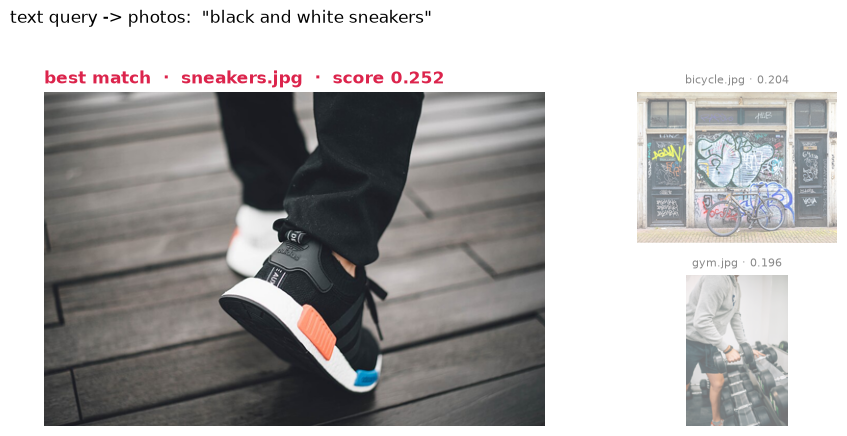

In [5]:
from qdrant_edge import Query, QueryRequest
from helper import embed_query_clip, show_photo_results

query = "black and white sneakers"
photo_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query_clip(query), using="image"),
        limit=3,
        with_payload=True,
    )
)
show_photo_results(photo_hits, "../data/images", query)

## 6. The photos on hand

These are the photos now in the store. Pick one to describe in the next cell.

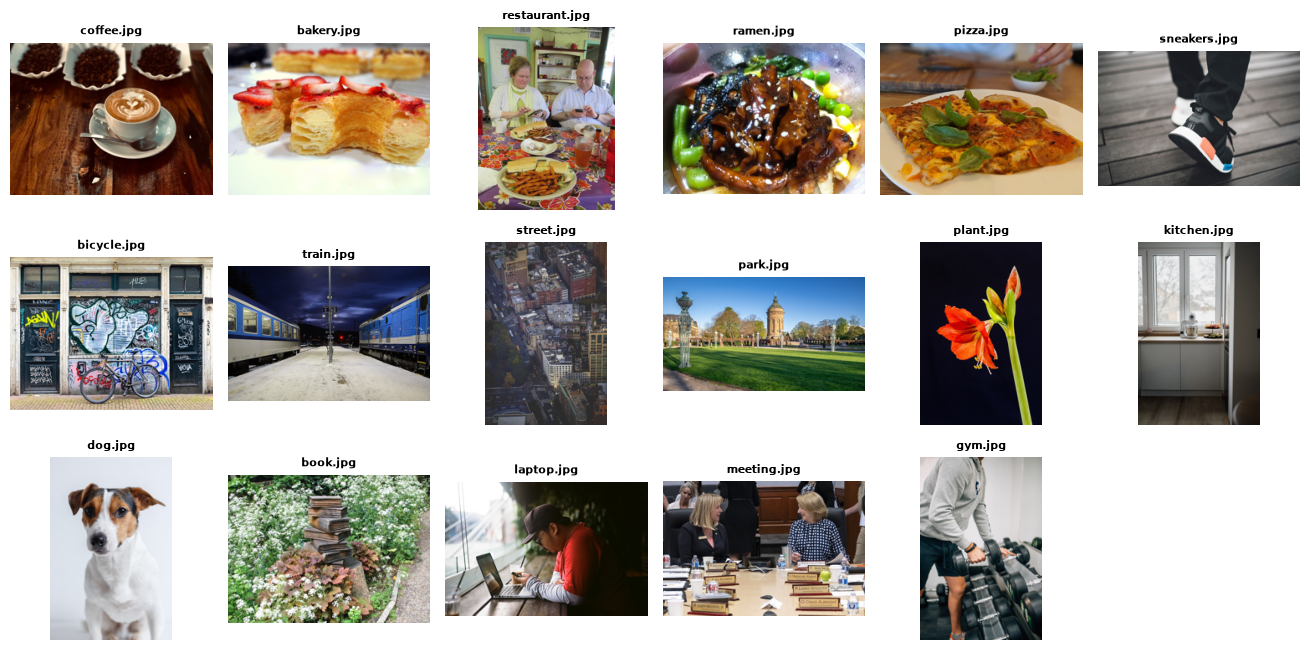

In [6]:
from helper import show_images

gallery = [f"../data/images/{m['file']}" for m in photos]
show_images(gallery, captions=[m["file"] for m in photos])

## 7. Your turn: describe a photo

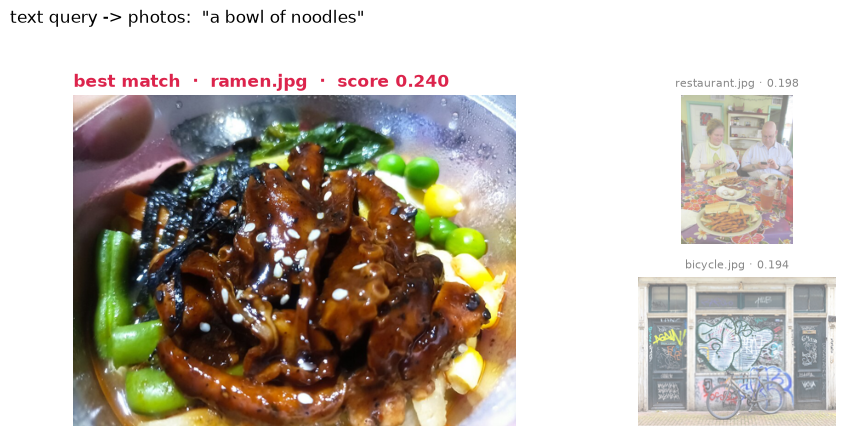

In [7]:
# Change this and re-run.
my_description = "a bowl of noodles"

photo_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query_clip(my_description), using="image"),
        limit=3,
        with_payload=True,
    )
)
show_photo_results(photo_hits, "../data/images", my_description)

## 8. Two spaces, shown side by side: never merged

Query sent to both vectors: "coffee"



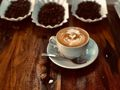

In [8]:
from helper import embed_query, memory_inbox

topic = "coffee"
text_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(topic), using="text"),
        limit=2,
        with_payload=True,
    )
)
image_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query_clip(topic), using="image"),
        limit=1,
        with_payload=True,
    )
)
print(f'Query sent to both vectors: "{topic}"')
memory_inbox({"Photos": image_hits, "Text Notes": text_hits}, "../data/images")

In [9]:
from helper import cleanup
cleanup(shard, "./mem_shard")
print("Cleaned up")

Cleaned up
